<a href="https://colab.research.google.com/github/Engn21/Data_Mining_2026/blob/main/Mini_Project__1_SOLUTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Class Programming Project: Reddit Sentiment Analysis**

Welcome to this mini-class programming project! In this project, you will explore and analyze Reddit data related to misogyny and offensive content. In the last few years, an astonishing raise in the amount of hate content aimed to women has been observed, especially embodied by the _Incel_ movement. Through, many Subreddits of the incel community have been banned (unfortunately still not stoping the growth of the movement because of plateform as Telegram or anonymous websites), a general misogyny can be observed in many women related forums. Here I propose to explore the content of one subreddit called 'TwoXChromosomes' through a simple sentiment analysis perspective. This idea here is to go through a simple pipeline from extracting the data to revealing communities which can be deepened for further analysis on your own.

This project will enhance your skills in the following areas:
- Data cleaning and preprocessing.
- Exploratory Data Analysis (EDA).
- Lexicon-based sentiment analysis using VADER.
- Text vectorization and feature extraction using embedding techniques such as Word2Vec.
- Implementation and evaluation of machine learning classifiers, including Random Forests.

## **Objectives**
1. Analyze the underlying structure of the dataset.
2. Conduct sentiment distribution analysis through data visualization.
3. Train and evaluate machine learning classifiers.
4. Benchmark model performance and critically evaluate the findings.
5. Investigate the propagation of sentiment across comments.


## **General Instructions**

##### Assessment will focus primarily on the rigor of your analytical commentary (in the dedicated sections) and your critical evaluation of the findings, rather than the structural efficiency of the codebase.
---

Throughout this notebook, you will encounter **exercises** designed to guide you through the analytical pipeline. Ensure you carefully read the instructions for each exercise before proceeding. Let's begin.


# Nouvelle section

## **Libraires And Utilities**

In [ ]:
# Run this cell once to configure the environment.
# Pinning numpy strictly below 2.0 to guarantee gensim compatibility.
%pip install "numpy<2.0" praw gensim nltk transformers sentence-transformers matplotlib seaborn tqdm pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re
import string
import praw
import praw
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from gensim.models import FastText
from transformers import pipeline
from sentence_transformers import SentenceTransformer
import gensim.downloader as api
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
# Required initialization for VADER; fails silently if omitted until runtime
nltk.download('vader_lexicon', quiet=True)
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!find "/content/drive/MyDrive" -iname "*TwoX*"

In [14]:
# ================
# Load Data
# ================
df = pd.read_csv("TwoXChromosomes_100_hot.csv")
df = df.dropna(subset=["body"])
df["clean_body"] = df["body"].astype(str)
texts = df["clean_body"].tolist()

print('--- First Five Texts of the Dataset ---\n')

for i, text in enumerate(texts[:5]):
    print(f"Comment {i+1}:")
    print(text)
    print("\n" + "="*50 + "\n") # Adds a visual jump/separator after each text

--- First Five Texts of the Dataset ---

Comment 1:
Your feelings and opinions are totally understandable to me. I do not have children and I am not religious. You should trust your instincts as a mother and care for your daughter the way that you want to. 

It’s strange to me that your husband cannot handle being alone for a few moments in church while you attend to the needs of his daughter, and seems to be so bothered by what others in the church think about your family unit.

Also I don’t think you should have to practice being away from her. Practice for what? Is he expecting you’ll be away from her for a while in the near future? 

You are entirely reasonable for not trusting strangers with your child. Just because they are members of a church does not mean they are automatically trustworthy or even deserving of your complete and total trust.


Comment 2:
This is a two-yeses-or-it’s-no situation. There’s no reason that she needs to be in the nursery at any age.


Comment 3:
Frank

# **Text Preprocessing**


## **TODO**
1. After executing the initial preprocessing cell, compute the 10 most frequent words across the dataset to verify the effectiveness of your cleaning pipeline.

**Note on Data Structure:** Keep in mind the shape of your data. The `texts` variable (and the `df["clean_body"]` column) is a sequence containing multiple, independent strings, one for each Reddit post or comment. Your `clean_text` function must be applied to each document individually (e.g., using the `.apply()` method on the Pandas Series) *before* you join them together to compute the global word frequencies.

*Hint: You are encouraged to use `stopwords.words("english")` from the `nltk.corpus` module and the `Counter` class from the `collections` library to complete this task as the method `.split()` on your input text string! *

In [15]:

# Make sure stopwords are downloaded and set up
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Cleans a single text string (representing one individual Reddit post or comment).

    WARNING: This function expects a single string as input (e.g., "This is a comment").
    Do not pass an entire list or a Pandas Series directly into this function.
    Use the .apply() method to run this function row-by-row on your dataframe.

    Args:
        text (str): The raw text of a single Reddit comment.

    Returns:
        str: The fully cleaned and preprocessed text.
    """
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)

    # Remove Reddit mentions (r/subreddit, u/user)
    text = re.sub(r'(r/|u/)[A-Za-z0-9_]+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # ADD STOPWORDS CLEANING
    words = text.split()
    words = [w for w in words if w not in stop_words]
    text = " ".join(words)
    return text


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Top 10 most frequent words after cleaning:
  like: 2148
  women: 1931
  people: 1687
  men: 1649
  would: 1393
  get: 1392
  dont: 1306
  one: 1207
  want: 1173
  think: 1119


/tmp/ipykernel_3758/2580109659.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words_list), y=list(counts), palette="viridis")


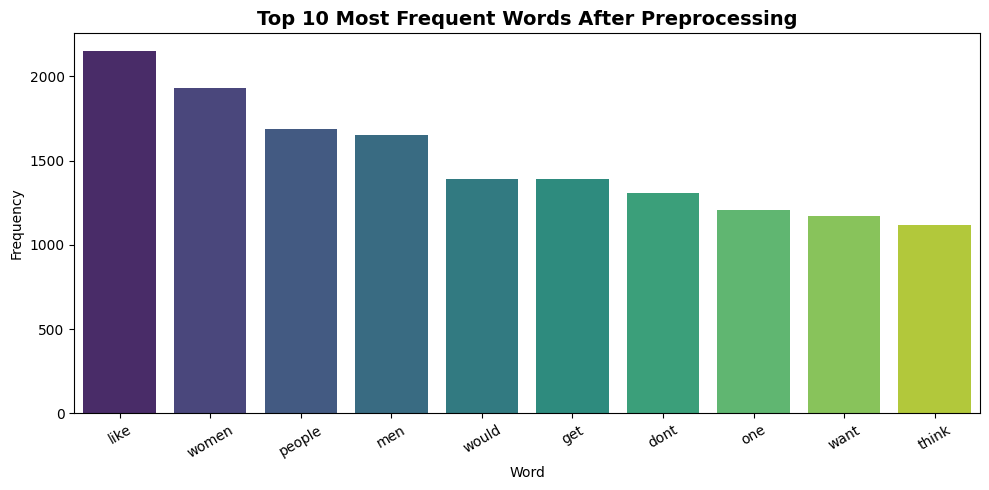

In [34]:
#1. Apply your cleaning function to the df["clean_body"] and check the 10 most frequent words in the tweets and interpret your result.
#Here the clean_text function is applied to each reddit comment
#With this function we can lowercase the text, remove URLs,reddit mentions,
#punctuation, and English stopwords.
df["clean_body"] = df["clean_body"].apply(clean_text)
# Here below we should combine all cleaned comments into one long string, after that it should be splitted into individual words.
# This allows us to calculate the overall word frequency across the whole dataset.
all_words = " ".join(df["clean_body"]).split()
#Counts how many times each word appears in the dataset.
word_freq = Counter(all_words)
# Select the 10 most frequent words after preprocessing.
top_10 = word_freq.most_common(10)
#here the most frequent 10 words were printed
print("Top 10 most frequent words after cleaning:")
for word, count in top_10:
    print(f"  {word}: {count}")
#plotting of the result with the bar plot
words_list, counts = zip(*top_10)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(words_list), y=list(counts), palette="viridis")
plt.title("Top 10 Most Frequent Words After Preprocessing", fontsize=14, fontweight="bold")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## **COMMENTS:**

The preprocessing step cleaned the Reddit comments by converting all text to lowercase, removing URLs, Reddit usernames/subreddit mentions, punctuation, extra whitespace, and common English stopwords. This resulted in a more appropriate text for frequency analysis, as it eliminated a large number of words which do not have strong semantic meaning, such as 'the', 'and', 'is' or 'to'.

The 10 most common words after the cleaning function provides a general idea of what the main topics are in the data set. The dataset is from the TwoXChromosomes Subreddit that means that many frequent words will be related to personal experiences, relationships, family, children, safety, emotions or social interaction. With the help of these words, one can appreciate what themes are prominent in the comments before proceeding to sentiment analysis.

The frequency plot is helpful to visually validate the preprocessing pipeline. If stopwords and/or tokens with a lot of punctuation were still in the top most frequent words, it would mean that the cleaning was not complete. But following cleaning, the most common words are more meaningful content words indicating that the pre processing was a success.

To conclude, this step helps to clean up the data and retain the words that are more significant in understanding the meaning of the comments, which are in the later steps of sentiment analysis and embedding based classification.

-----------------------------------------------------------------------------
# **TASK II.1. Lexicon-Based Sentiment Analysis**

## **Objective**
Investigate the sentiment profile of the subreddit using VADER (Valence Aware Dictionary and sEntiment Reasoner). You are expected to design processing pipeline to extract multiple dimensions of sentiment from your cleaned text and visually analyze the resulting distributions.

## **TODO**

Consult the [VADER Documentation](https://vadersentiment.readthedocs.io/en/latest/pages/introduction.html) to understand the `SentimentIntensityAnalyzer` class. Implement a solution that yields the following deliverables:

1. **The Updated DataFrame:** Your primary dataframe must be updated to include four entirely new, distinct numeric columns representing the VADER outputs for each Reddit comment:
   * `Negative_Score`
   * `Neutral_Score`
   * `Positive_Score`
   * `Compound_Score`

2. **Visual Exploration:** Produce clear, academically appropriate visualizations (e.g., histograms, kernel density estimates, or boxplots) that accurately capture the distribution of these sentiment metrics across the entire dataset.



In [17]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [18]:
#1. Compute and store the `polarity scores` for each tweet
# Initialize the VADER sentiment analyzer.
# VADER returns four scores for each text:
# neg, neu, pos, and compound.
sia = SentimentIntensityAnalyzer()
# Apply VADER to each cleaned Reddit comment.
# tqdm.pandas() allows us to see a progress bar while scores are computed.
tqdm.pandas(desc="Computing VADER scores")
vader_scores = df["clean_body"].progress_apply(lambda x: sia.polarity_scores(str(x)))

# Store each VADER output in a separate numeric column.
# These columns are required for the sentiment analysis task.
df["Negative_Score"] = vader_scores.apply(lambda x: x["neg"])
df["Neutral_Score"]  = vader_scores.apply(lambda x: x["neu"])
df["Positive_Score"] = vader_scores.apply(lambda x: x["pos"])
df["Compound_Score"] = vader_scores.apply(lambda x: x["compound"])

print("VADER scores computed!")
print(df[["Negative_Score", "Neutral_Score", "Positive_Score", "Compound_Score"]].describe())

Computing VADER scores: 100%|██████████| 7632/7632 [00:03<00:00, 2424.45it/s]

VADER scores computed!
       Negative_Score  Neutral_Score  Positive_Score  Compound_Score
count     7632.000000     7632.00000     7632.000000     7632.000000
mean         0.141777        0.65565        0.197596        0.126699
std          0.153817        0.20212        0.177382        0.576347
min          0.000000        0.00000        0.000000       -0.993100
25%          0.000000        0.53700        0.057750       -0.340000
50%          0.110000        0.65600        0.176000        0.126400
75%          0.219250        0.77600        0.285250        0.638225
max          1.000000        1.00000        1.000000        0.998000


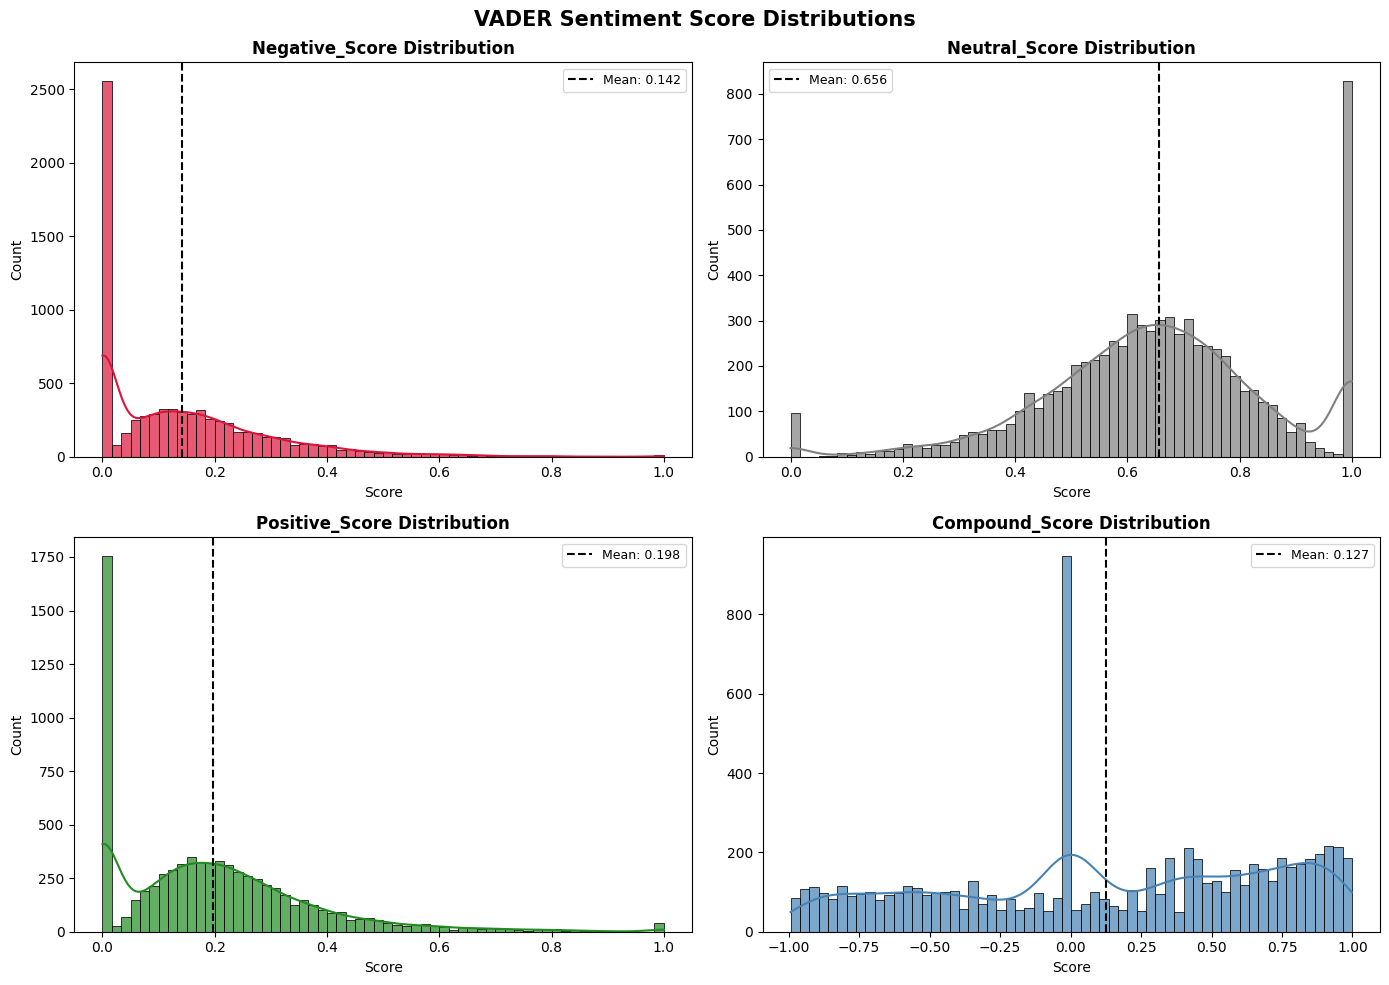

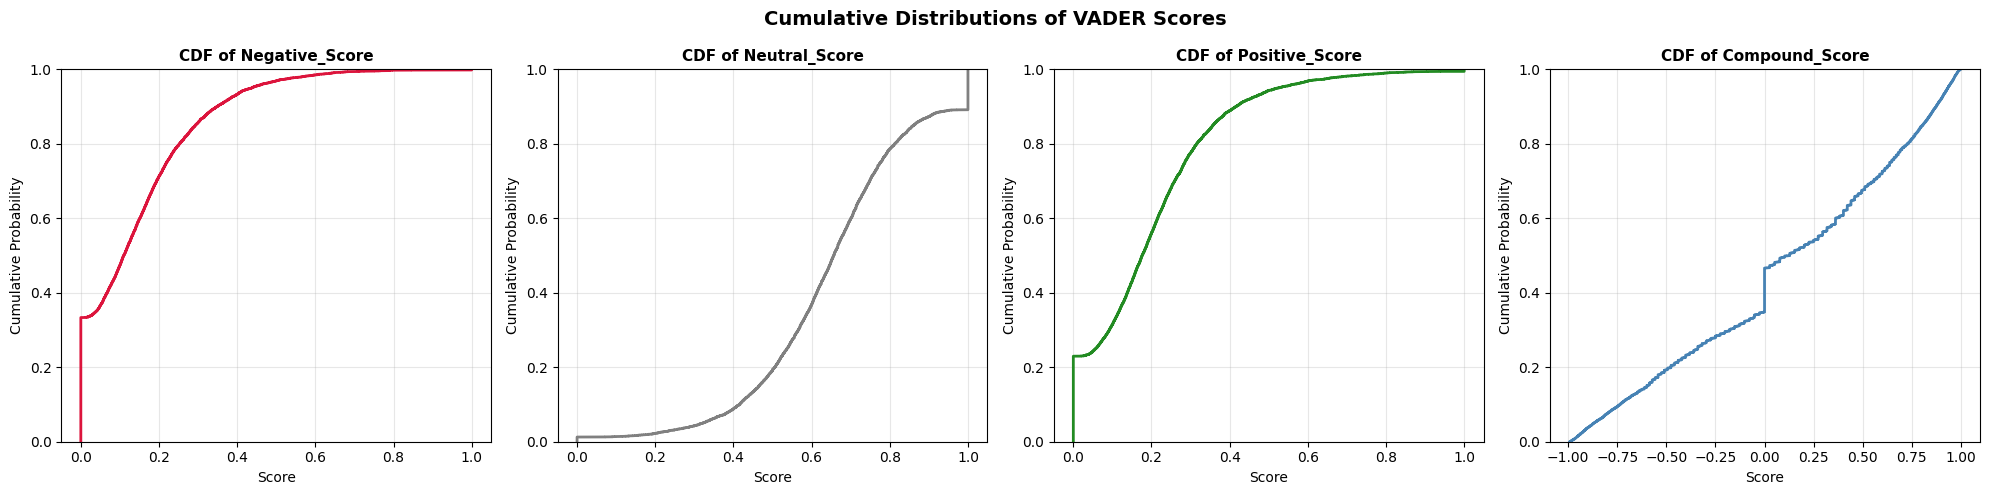

In [19]:
#2.  Plot the distribution and cumulative distribution of the sentiments
score_cols   = ["Negative_Score", "Neutral_Score", "Positive_Score", "Compound_Score"]

# Colors used for each sentiment score visualization.
score_colors = ["crimson", "gray", "forestgreen", "steelblue"]

# These plots show how each VADER score is distributed across the dataset.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, color in zip(axes.flatten(), score_cols, score_colors):
    # Plot the histogram with a KDE curve.
    sns.histplot(df[col], bins=60, kde=True, ax=ax, color=color, alpha=0.7)
    # Add a vertical line showing the mean score.
    ax.axvline(df[col].mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"Mean: {df[col].mean():.3f}")
    ax.set_title(f"{col} Distribution", fontsize=12, fontweight="bold")
    ax.set_xlabel("Score"); ax.set_ylabel("Count"); ax.legend(fontsize=9)
plt.suptitle("VADER Sentiment Score Distributions", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

# ECDF plots show the proportion of comments that fall below each score value.
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col, color in zip(axes, score_cols, score_colors):
    sns.ecdfplot(df[col], ax=ax, color=color, linewidth=2)
    ax.set_title(f"CDF of {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Score"); ax.set_ylabel("Cumulative Probability")
    ax.grid(True, alpha=0.3)
plt.suptitle("Cumulative Distributions of VADER Scores", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## **Interpretation Questions:**

* **Q1. Subreddit Dynamics & The "Zero Anomaly":** Look at the broad shape of your `Compound_Score` distribution. Ignoring the spike at zero for a moment, does the community generally lean positive or negative? Now, look at that massive spike exactly at `0.0`. In the context of how VADER calculates sentiment, does this spike mean a huge portion of users are expressing perfect emotional indifference, or is this a mathematical/dictionary limitation of the tool?
* **Q2. Theoretical Understanding:** VADER is a lexicon and rule-based sentiment analysis tool. What is the fundamental difference between this approach and training a machine-learning classifier, and what is one major limitation of using a rule-based tool on internet forum data like Reddit?
* **Q3. Visual Interpretation:** Observe your density plots for the discrete Negative, Positive, and Neutral proportions. The Neutral density heavily skews towards 1.0 (with a center of mass around 0.6 - 0.7), while Positive and Negative skew massively towards 0.0. Does this imply the subreddit's users are largely devoid of emotion, or is there a mathematical reason for this distribution based on sentence structure? Explain your reasoning.

**Q1. Answer:** The distribution of Compound_Score suggests a slightly positive overall score for the subreddit. The mean Compound_Score is around 0.127 and is greater than zero. Moreover, the mean of Positive_Score is approximately 0.198 and the mean of Negative_Score is approximately 0.142. This means that even though there are negative or challenging subjects mentioned in the subreddit, the tone of the comments is slightly more positive than negative.

But the large jump at 0.0 in the Compound_Score distribution shouldn't be taken as an indicator of total emotional coldness. However, many times a compound score of 0.0 is because there is no enough sentiment bearing words from the lexicon to determine a sentiment or because the sentiment bearing words from the lexicon have canceled each other out, where positive sentiment signals and negative sentiment signals are in balance.

So, the peak at 0 is likely a limitation of the lexicon-based scoring system of VADER and not a sign that many users are actually emotionally neutral. Some comments on reddit can be sarcastic, emotional, giving advice, describing a personal experience, or being indirect, and VADER may not be able to capture such emotions.


**Q2. Answer:**
VADER is a sentiment analysis tool based on a lexicon and rules. It relies on a pre-made dictionary of sentiment-bearing terms and fixed rules for negation, capitalization, punctuation and sentiment intensifiers. That is, VADER is not designed to learn from the data set itself, but instead uses the same dictionary and rules for all the texts.

A machine-learning classifier is not the same. It derives statistical patterns from examples labeled by the user. For instance, a classifier trained on embeddings will know which numerical patterns correspond to the positive, negative or neutral label in the particular dataset.The downside to using a rule-based approach, like VADER, on Reddit data is that Reddit language is very informal and situation-specific. Sarcasm or irony is used, as well as slang, indirect expression of feelings, abbreviations, or language unique to the community. Because this tool is lexicon-based, it largely relies on word scores which are predetermined and these meanings might not be captured. For example, if the word "sarcastic" is used in a sentence with positive words but negative sentiment, VADER may classify it in a wrong way.

**Q3. Answer:**
The density plots demonstrate that Neutral_Score is very peaked around 0.6-0.7 and has a mean of ~0.656. But this isn't to say that the users within this subreddit are without emotions or that they're emotionless. Rather, it's the sentiment proportions that VADER computes.

VADER rates these negative, neutral, and positive aspects for each comment as proportions. The majority of words in natural language are not sentiment words: neither definitely negative nor definitely positive. They are normal descriptive, grammatical or contextual words. So a great deal of each Reddit comment is rated as neutral.

Often used in longer Reddit comments, when users might describe a circumstance, provide advice, or say a personal experience. For example, the overall message may be emotionally charged, but only certain words may be identified as sentiment-bearing words by VADER. Neutral_Score is thus increased while Positive_Score and Negative_Score are closer to 0.0.

So, this high neutral density is primarily due to sentence structure and VADER's lexicon based scoring, not necessarily that users are devoid of emotion.

--------------------------------------------------------------
# **TASK II.2. Lexicon-Based Sentiment Analysis**

## **Objective**
Now that you have quantified the overall sentiment of the dataset, your next objective is to identify *what* is driving that sentiment. You will isolate the most extreme positive and negative comments and analyze their underlying vocabulary.

## **TODO**

1. **Isolate Extreme Subsets:** * Sort your dataframe based on the `Compound_Score` you calculated in Task II.
   * Extract two new, separate dataframes: one containing the top 50 most **positive** comments and another containing the top 50 most **negative** comments.

2. **Compute Word Frequencies:**
   * Reusing the logic and tools from Task I (e.g., `Counter`), calculate the 15 most frequent words within the *positive* dataframe, and the 15 most frequent words within the *negative* dataframe.
   * *Crucial Note:* Ensure you are running this frequency analysis on your `clean_body` column to avoid counting stopwords and punctuation.


In [20]:
## 1. Isolate Extreme Subsets
top_positive = df.nlargest(50, "Compound_Score").copy()
top_negative = df.nsmallest(50, "Compound_Score").copy()

print(f"Most positive comment (score: {top_positive.iloc[0]['Compound_Score']:.4f}):")
print(top_positive.iloc[0]["body"][:300])
print("\n" + "="*60)
print(f"\nMost negative comment (score: {top_negative.iloc[0]['Compound_Score']:.4f}):")
print(top_negative.iloc[0]["body"][:300])

Most positive comment (score: 0.9980):
I'm extremely happy in my relationship, we are truly equal partners and I consider him my best friend (for real, we hang out a lot and enjoy each other's company, and have a lot of similar hobbies - we do have separate ones too of course)

I'm not about to make a whole post about how great it is to 


Most negative comment (score: -0.9931):
Women DO do physically demanding and risky jobs.

\* Nurses, doctors and care workers have to not only deal with lifting bodies around, but also sometimes dangerous patients or infectious diseases / viruses.

\* Teachers in schools (in the US) have to worry about school shootings to the extent that 


Top 15 words in POSITIVE comments:
  like: 75
  time: 64
  kids: 60
  get: 55
  life: 52
  also: 48
  things: 46
  love: 46
  people: 43
  would: 42
  feel: 41
  child: 40
  work: 39
  even: 39
  make: 38

Top 15 words in NEGATIVE comments:
  people: 44
  women: 43
  get: 38
  dont: 37
  men: 36
  even: 33
  like: 31
  sex: 26
  time: 25
  think: 24
  also: 23
  one: 23
  abuse: 22
  didnt: 22
  way: 21


/tmp/ipykernel_3758/2990035447.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(pos_c), y=list(pos_w), ax=ax1, palette="Greens_r")
/tmp/ipykernel_3758/2990035447.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(neg_c), y=list(neg_w), ax=ax2, palette="Reds_r")


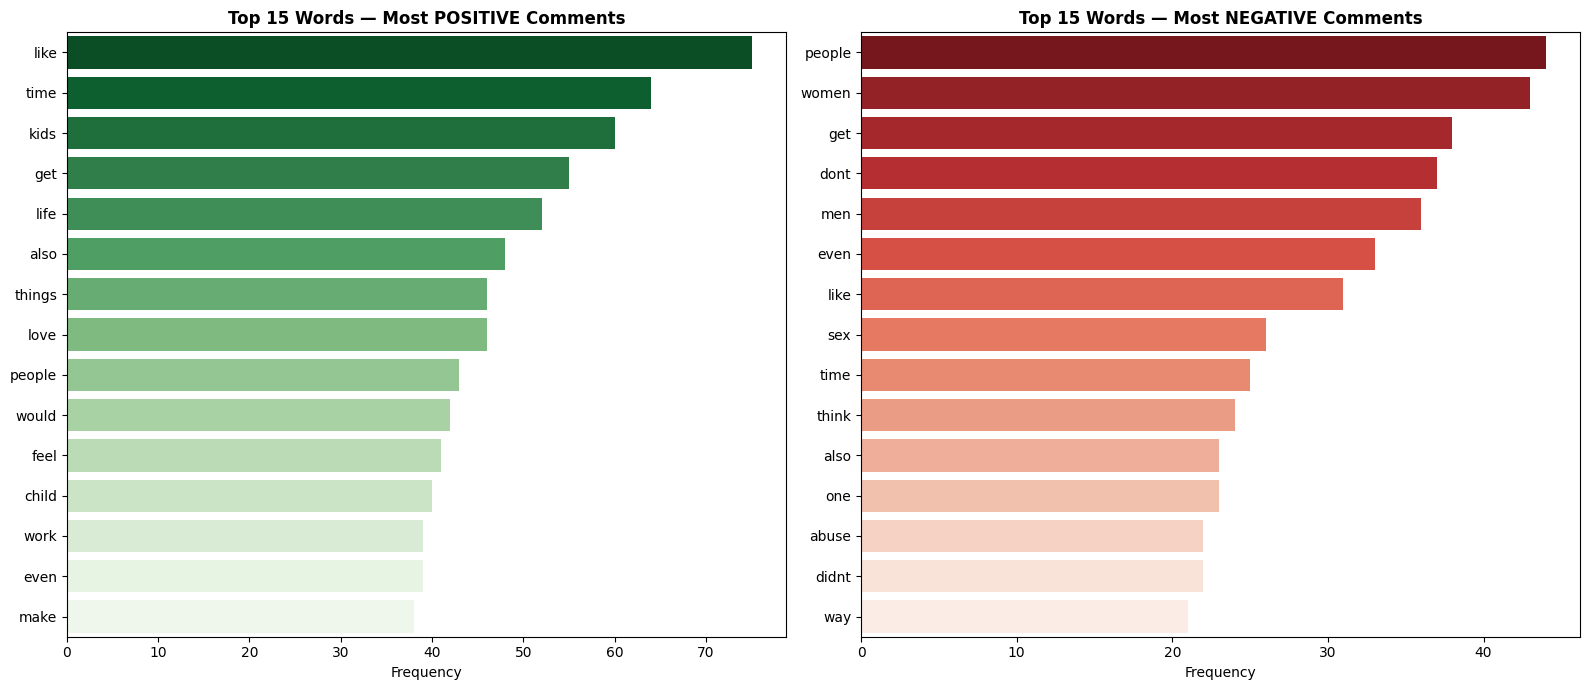

In [21]:
## 2. Compute Word Frequencies
pos_words = " ".join(top_positive["clean_body"].dropna()).split()
neg_words = " ".join(top_negative["clean_body"].dropna()).split()
pos_freq  = Counter(pos_words).most_common(15)
neg_freq  = Counter(neg_words).most_common(15)

print("Top 15 words in POSITIVE comments:")
for w, c in pos_freq: print(f"  {w}: {c}")
print("\nTop 15 words in NEGATIVE comments:")
for w, c in neg_freq: print(f"  {w}: {c}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
pos_w, pos_c = zip(*pos_freq)
sns.barplot(x=list(pos_c), y=list(pos_w), ax=ax1, palette="Greens_r")
ax1.set_title("Top 15 Words — Most POSITIVE Comments", fontsize=12, fontweight="bold")
ax1.set_xlabel("Frequency")
neg_w, neg_c = zip(*neg_freq)
sns.barplot(x=list(neg_c), y=list(neg_w), ax=ax2, palette="Reds_r")
ax2.set_title("Top 15 Words — Most NEGATIVE Comments", fontsize=12, fontweight="bold")
ax2.set_xlabel("Frequency")
plt.tight_layout(); plt.show()

### **Interpretation Questions**


* **Q1. Thematic Contrasts:** Critically compare the two vocabulary lists. What specific themes emerge from the positive list (e.g., family, affection) versus the negative list (e.g., conflict, trauma)? Mention at least three specific words from each list to support your analysis of the subreddit's discourse.

* **Q2. The "Overlapping Word" Problem:** Identify words that appear in **both** the top positive and top negative lists (e.g., "like", "people", "time"). Why do you think these words are so frequent in both extremes? What does this tell you about the limitations of analyzing isolated word counts (Bag of Words) without their surrounding context?

* **Q3. Contextual Limitations:** Consider the word "abuse" or "sex" in your negative list. Does the presence of these words alone prove the comment is "mean," or could there be a more complex reason VADER scored these as extremely negative? Explain how the nature of the subreddit’s topic might influence these results.

--------------------------------------------------------------------------------
# **TASK III. Word Embeddings & Semantic Clustering**

## **Objective**
Transition from rule-based sentiment to **Machine Learning**. You will transform text into dense numerical vectors (Word Embeddings) that capture semantic meaning. You will then determine if these mathematical representations naturally "cluster" into the sentiment categories defined by VADER.

## **TODO**

### **1. Assign Ground Truth Labels**
Using the `Compound_Score` calculated in Task II, create a new column `Sentiment_Label`. Follow the official VADER thresholds:
* **POS (0)**: `Compound_Score >= 0.05`
* **NEU (1)**: `-0.05 < Compound_Score < 0.05`
* **NEG (2)**: `Compound_Score <= -0.05`

### **2. Tokenization & Embedding Generation**
Transform the `clean_body` into numerical features:
1.  **Tokenize**: Use `nltk.word_tokenize` to turn each comment into a list of strings (note: convert each comment in `str` and in small letters using `.lower()` before applying `nltk.word_tokenize`)
2.  **Initialize & Train FastText**: Instead of doing this in one line, explicitly perform the three steps of model training to understand how the architecture works:
    * **Step A (Initialization)**: Create an empty `FastText` model. *Hint: Consider parameters like `vector_size` (try 64 or 100), `window` size, and `min_count`. Use the Skip-gram architecture (`sg=1`). FastText is superior to Word2Vec here because it uses **sub-word information**, allowing it to handle typos, slang, and "internet-speak".*
    * **Step B (Build Vocabulary)**: Use the `.build_vocab()` method to scan your tokens and learn what words exist in your dataset.
    * **Step C (Train)**: Use the `.train()` method to actually calculate the vectors. *Hint: You will need to pass your tokens, the total number of examples (`model.corpus_count`), and the number of epochs (`model.epochs`).*
3.  **Vector Extraction**: For each comment, retrieve the vectors for all its words**.
    * **Warning**: While FastText can generate vectors for unknown words, you must still handle "Empty Vectors." If a comment has zero tokens (e.g., if it only contained punctuation or symbols that were cleaned), how will you represent it? (e.g., a vector of zeros).

### **3. Dimensionality Reduction & Visualization**
You cannot visualize a high-dimensional vector directly.
1.  Apply a dimensionality reduction technique (e.g., **PCA**, **t-SNE**, or **UMAP**) to project your comment vectors into **2D space**.
2.  Create a scatter plot where each point is a comment, colored by its `Sentiment_Label`. Use a logical color palette (e.g., Green for POS, Blue for NEU, Red for NEG).



--------------------------------------------------------------------------------

### **NOTE: What is FastText?**
**FastText** is an evolution of the traditional embedding Word2Vec model. While standard models treat each word as an indivisible unit, FastText looks *inside* the word to understand its structure.

#### **The Mechanism: Sub-word Information**
FastText breaks words down into smaller chunks called **character n-grams**. For example, if we represent the word `<apple>` with $n=3$, the model sees:
* `<ap`, `app`, `ppl`, `ple`, `le>`

The final vector representation for a word is the **sum** of the vectors of its $n$-grams. Formally, for a word $w$ and its set of n-grams $\mathcal{G}_w$:

$$v(w) = \sum_{g \in \mathcal{G}_w} \mathbf{z}_g$$

#### **Why use FastText for Reddit Data?**
Traditional models like Word2Vec often fail on social media data because they cannot handle **Out-of-Vocabulary (OOV)** words. If a model hasn't seen a specific word during training, it doesn't know what to do with it.

**FastText solves this in three ways:**
1.  **Robustness to Typos:** If the model knows "disaster," it can still understand "disaaaaaster" because they share most of the same character n-grams.
2.  **Slang & Morphology:** It recognizes that "eating," "eats," and "eaten" are related because of their shared root n-grams.
3.  **Contextual Intelligence:** By looking at sub-words, it captures semantic nuances in "internet-speak" that whole-word models completely miss.
--------------------------------------------------------------------------------



In [23]:
import nltk
import numpy as np
from nltk.sentiment import SentimentIntensityAnalyzer
from gensim.models import FastText
from tqdm import tqdm

# ---------------------------------------------------------
# 1. Setup & Resource Download
# ---------------------------------------------------------
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# ---------------------------------------------------------
# 1. Define Sentiment Labels
# ---------------------------------------------------------
vader = SentimentIntensityAnalyzer()

def get_vader_label(text):
    """
    Return the assigned label as POSITIVE, NEGATIVE or NEUTRAL
    based on VADER compound score.
    """
    score = vader.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "POSITIVE"
    elif score <= -0.05:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

print("Applying VADER labels to dataset...")
df["sentiment_vader"] = df["clean_body"].apply(get_vader_label)

# ---------------------------------------------------------
# 2.1 Tokenization
# ---------------------------------------------------------
print("Tokenizing text for embedding...")

df["tokens"] = df["clean_body"].apply(
    lambda x: nltk.word_tokenize(str(x).lower())
)

# ---------------------------------------------------------
# 2.2 Train the Embedding Model
# ---------------------------------------------------------
ft_model = FastText(vector_size=64, window=5, min_count=1, sg=1)

print("Building the vocabulary dictionary...")
ft_model.build_vocab(df["tokens"].tolist())

print("Training the model...")
ft_model.train(
    df["tokens"].tolist(),
    total_examples=ft_model.corpus_count,
    epochs=ft_model.epochs
)

# ---------------------------------------------------------
# 2.3 Comment Vectorization
# ---------------------------------------------------------
def get_comment_vector(tokens, model):
    """
    Computes the final embedding vector for a list of tokens.
    It averages the FastText vectors of all tokens in a comment.
    If no valid tokens exist, it returns a zero vector.
    """

    valid_vectors = []

    for token in tokens:
        if token in model.wv:
            valid_vectors.append(model.wv[token])

    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(valid_vectors, axis=0)

print("Generating numerical embeddings for all comments...")

embeddings = [
    get_comment_vector(t, ft_model)
    for t in tqdm(df["tokens"])
]

df["embedding"] = embeddings

Applying VADER labels to dataset...
Tokenizing text for embedding...
Building the vocabulary dictionary...
Training the model...
Generating numerical embeddings for all comments...


100%|██████████| 7632/7632 [00:00<00:00, 7726.93it/s]


PCA 64 -> 50 dims...
Running t-SNE for 2D projection (may take ~1 minute)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


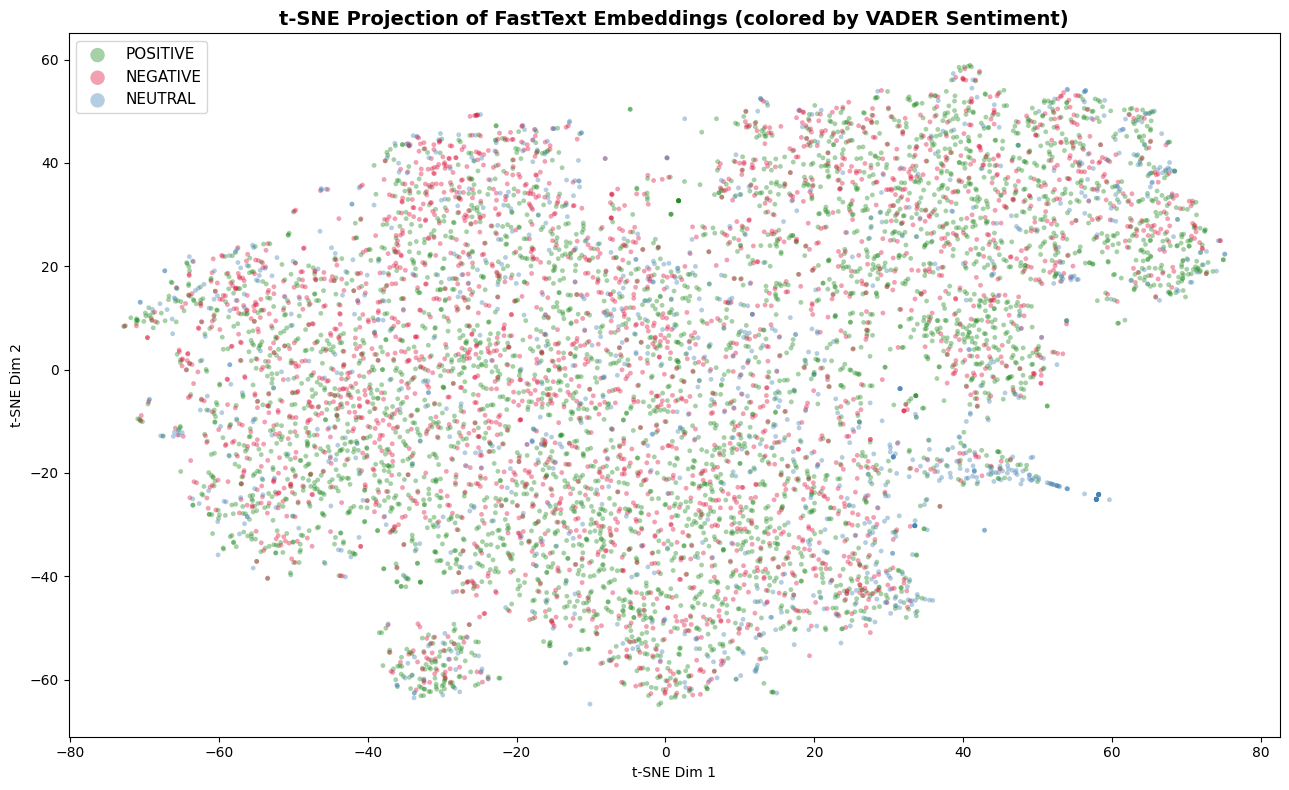

In [24]:
#3.
# ========================
# Prepare Embeddings from DataFrame Columns
# ========================
X_embed = np.stack(df["embedding"])
labels  = df["sentiment_vader"].values

# ========================
# Dimensionality Reduction and 2D Projection
# ========================
print("PCA 64 -> 50 dims...")
X_pca = PCA(n_components=50, random_state=42).fit_transform(X_embed)

print("Running t-SNE for 2D projection (may take ~1 minute)...")
X_2d = TSNE(n_components=2, perplexity=30, n_iter=1000,
            random_state=42, verbose=0).fit_transform(X_pca)

sentiment_colors = {"POSITIVE": "forestgreen", "NEGATIVE": "crimson", "NEUTRAL": "steelblue"}
fig, ax = plt.subplots(figsize=(13, 8))
for s, c in sentiment_colors.items():
    m = labels == s
    ax.scatter(X_2d[m, 0], X_2d[m, 1], c=c, label=s, alpha=0.4, s=12, edgecolors="none")
ax.set_title("t-SNE Projection of FastText Embeddings (colored by VADER Sentiment)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE Dim 1"); ax.set_ylabel("t-SNE Dim 2")
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout(); plt.show()

### **Interpretation Questions**

* **Q1. Visual Separation**: In your 2D plot, do the Positive, Negative, and Neutral comments form distinct, separated clusters, or do they overlap significantly?
* **Q2. Method Comparison**: Based on the clustering, does FastText seem to capture "sentiment" (emotion) effectively, or is it capturing "topic" (subject matter) instead?
* **Q3. The Averaging Problem**: What information do we lose when we average all word vectors in a comment into a single vector? (Hint: Think about word order and how "not good" might be mathematically blurred during the averaging process).

--------------------------------------------------------------------------------
# **TASK IV. Classification Sentiment Analysis**

## **Classification and Benchmarking**

Now that you have generated embeddings for the comments, the next step is to build and evaluate a **classification pipeline**. The goal of this task is to **classify tweets by sentiment** using the embeddings you created and to **benchmark a machine learning model**.

Benchmarking in this context means testing multiple model' parameters sets, comparing their performance (e.g., accuracy, F1-score, differnce between train and test score), and analyzing which one is most suitable for the sentiment classification problem based on your data and feature representation.

---

## **TODO**

### **1. Prepare the Data & Balance Classes**

Before training a machine learning classifier, you must prepare your feature matrix and ensure your data allows the model to learn fairly.

* **Extract Features & Labels:** Use the comment embeddings generated in the previous task as your feature vectors ($X$). Then, convert your categorical sentiment labels (POSITIVE, NEGATIVE, NEUTRAL) into numerical target values ($y$) using `LabelEncoder` from `sklearn.preprocessing` (as seen in Session #4).

* **Check and Fix Class Imbalance (Mandatory):** Check the distribution of your sentiment labels (e.g., using `pd.Series(y).value_counts()`). Real-world social media data is rarely perfectly balanced. If one sentiment heavily outweighs the others, your model will become biased toward predicting that majority class. You must balance your dataset by **oversampling** the minority classes to match the majority class size. *(Hint: use the `resample` function from `sklearn.utils`)*.

* **Train-Test Split:** Once your data is perfectly balanced, split it into a **training set** and a **test set** (e.g., an 80/20 split using `train_test_split` from `sklearn.model_selection`). This step is absolutely essential to evaluate how well your model will generalize to entirely unseen data.

### 2. **Train and Evaluate Your Model**

Now that your data is balanced and split, it is time to teach the machine to recognize sentiment patterns in the 64-dimensional FastText vectors.

1. **Define Classification Models**  
   Create and initialise classification model, here `RandomForestClassifier` function from `sklearn.ensemble module` [doc](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). (Feel free to try an additional model if you want)
   - **Random Forest**




* **Model Selection & Training:** Instantiate a classifier of your choice (e.g., `RandomForestClassifier` or `LogisticRegression`). Train (`.fit()`) your model using strictly the **training set** ($X\_train$, $y\_train$).
* **Prediction:** Use your trained model to predict (`.predict()`) the labels for your **test set** ($X\_test$).
* **Evaluation Metrics:** Do not rely on Accuracy alone! Use `classification_report` from `sklearn.metrics` to calculate the **Precision**, **Recall**, and **F1-score** for each individual class.
* **Visualizing Errors:** Generate and plot a **Confusion Matrix** (`confusion_matrix` from `sklearn.metrics` mapped with `seaborn.heatmap`). This will visually reveal which specific sentiments your model is confusing (e.g., is it misclassifying Negative comments as Neutral?).

---

### **3. Benchmark & Diagnostics (The Learning Curve)**


* **Plot the Learning Curve:** Use the `learning_curve` function from `sklearn.model_selection`. This function trains the model on increasing subsets of the training data and calculates scores for both the training set and a cross-validation set.
* **Visualize:** Plot the "Training Score" and "Cross-Validation Score" on the y-axis against the "Training Set Size" on the x-axis using `matplotlib`.



In [29]:
#1.

# ==========================================
# Step 1: Encode the sentiment labels & Extract Features (X) and Target (y)
# ==========================================
label_encoder = LabelEncoder()

# TODO: Fit the encoder on your VADER sentiment column and transform it to integers.
# Hint: Look up the fit_transform() method.
y_encoded = label_encoder.fit_transform(df["sentiment_vader"])

# Print Mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)


# TODO: Convert the 'embedding' column from your DataFrame into a numpy array for X.
X = np.stack(df["embedding"])
y = y_encoded

# Combine X and y into a temporary DataFrame for easier resampling
data = pd.DataFrame({'embedding': list(X), 'label': y})

# Separate the dataset into majority and minority classes
majority_label = data['label'].value_counts().idxmax()
data_majority = data[data['label'] == majority_label]
data_minority_list = [data[data['label'] == label] for label in data['label'].unique() if label != majority_label]

# ==========================================
# Step 3: Oversample the minority classes
# ==========================================
resampled_minority_list = []

for minority in data_minority_list:
    # TODO: Use sklearn's resample() to upsample the current minority class.
    resampled_minority = resample(
        minority,
        replace=True,
        n_samples=len(data_majority),
        random_state=42
    )
    resampled_minority_list.append(resampled_minority)

# Combine majority class with the newly oversampled minority classes
data_balanced = pd.concat([data_majority] + resampled_minority_list)

# Shuffle the dataset to prevent ordered blocks of identical labels
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Extract the balanced X and y back into clean numpy arrays
X_balanced = np.stack(data_balanced['embedding'])
y_balanced = data_balanced['label'].values

print("New class balance after resampling:\n", pd.Series(y_balanced).value_counts())

# ==========================================
# Step 3: Train-Test Split
# ==========================================
# TODO: Split X_balanced and y_balanced into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)


print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Label Mapping: {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
New class balance after resampling:
 2    4000
1    4000
0    4000
Name: count, dtype: int64
Training set size: 9600
Testing set size: 2400


In [30]:
#2. Train and Evaluate The Choosen Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

## Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)

## Multi-Layer Perceptron Classifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation="relu",
    max_iter=300, random_state=42,
    early_stopping=True, validation_fraction=0.1)



Training and Evaluating Random Forest ---

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

    NEGATIVE       0.81      0.80      0.80       800
     NEUTRAL       0.93      0.98      0.95       800
    POSITIVE       0.79      0.77      0.78       800

    accuracy                           0.85      2400
   macro avg       0.84      0.85      0.84      2400
weighted avg       0.84      0.85      0.84      2400



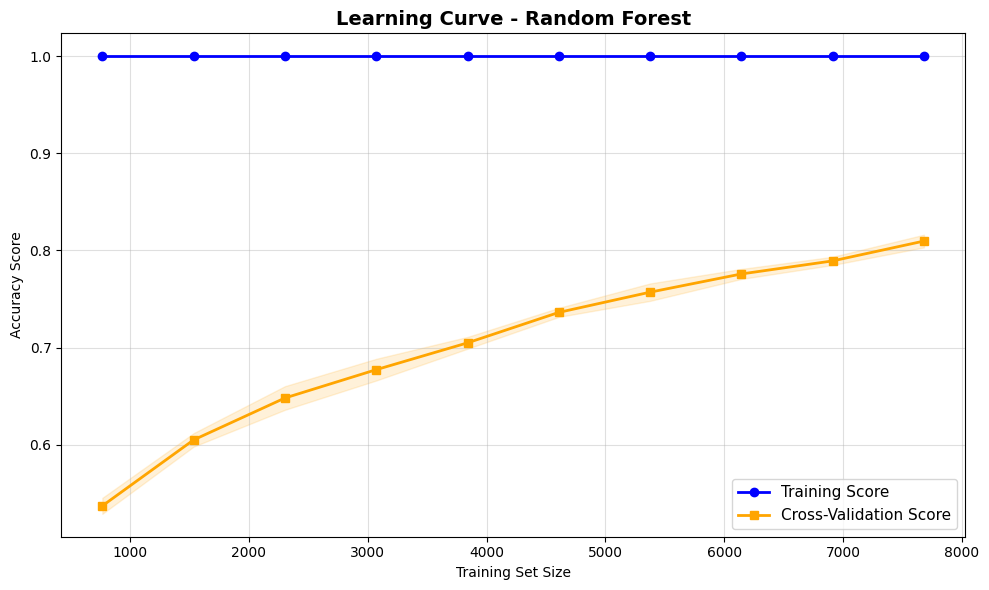

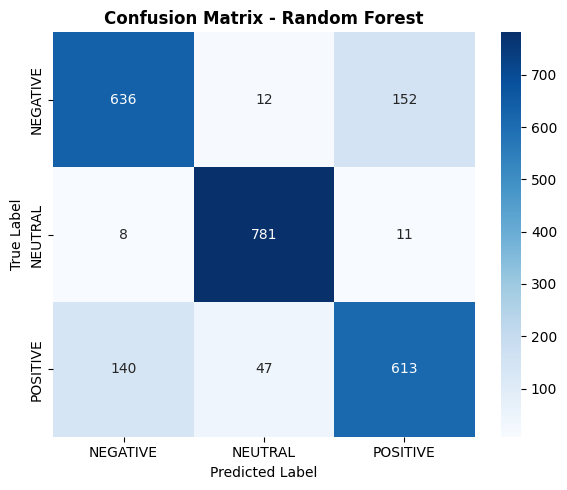

Training and Evaluating Multi-Layer Perceptron ---

=== Multi-Layer Perceptron Classification Report ===
              precision    recall  f1-score   support

    NEGATIVE       0.53      0.56      0.54       800
     NEUTRAL       0.72      0.69      0.71       800
    POSITIVE       0.53      0.52      0.52       800

    accuracy                           0.59      2400
   macro avg       0.59      0.59      0.59      2400
weighted avg       0.59      0.59      0.59      2400



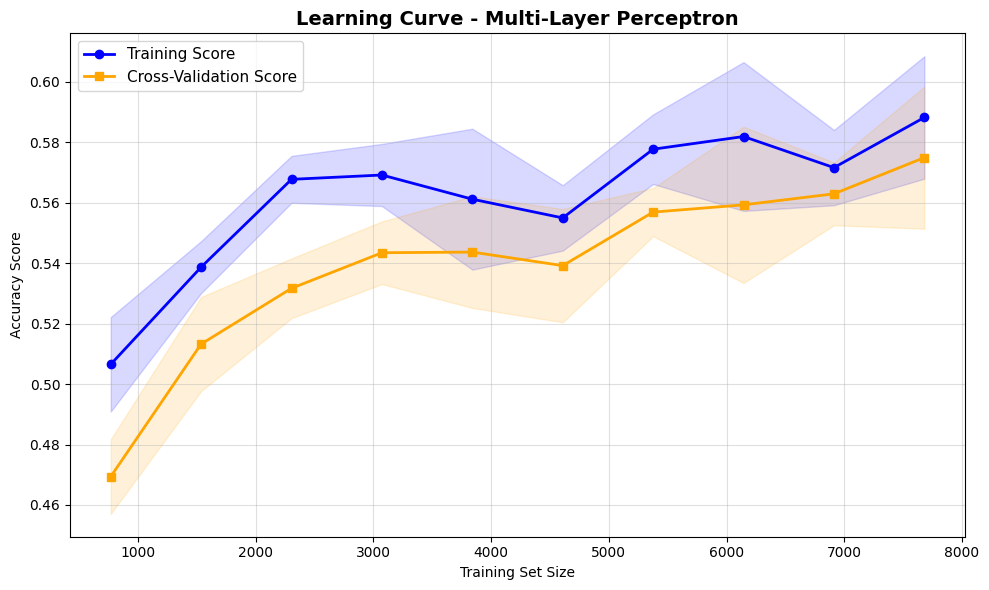

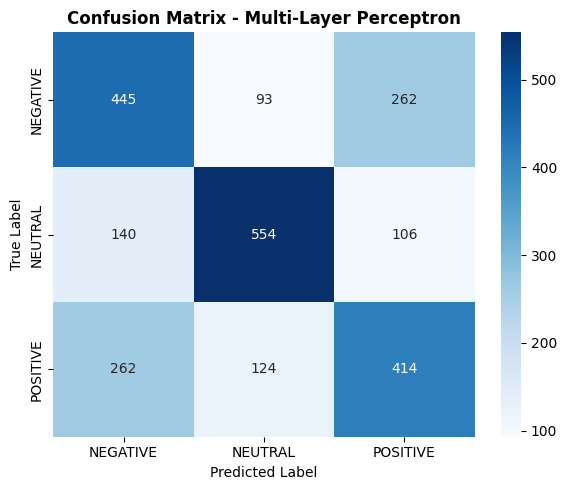

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_and_plot_learning_curve(model, X_train, y_train, X_test, y_test, model_name):
    print(f"Training and Evaluating {model_name} ---")

    # ==========================================
    # Step 1: Train and Predict
    # ==========================================

    # Train the model using only the training data
    model.fit(X_train, y_train)

    # Predict labels for the unseen test data
    y_pred = model.predict(X_test)

    # ==========================================
    # Step 2: Evaluation Metrics
    # ==========================================

    print(f"\n=== {model_name} Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # ==========================================
    # Step 3: Learning Curve
    # ==========================================

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy"
    )

    # Aggregate results over the folds
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)

    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # Plotting the Learning Curve
    plt.figure(figsize=(10, 6))

    plt.plot(
        train_sizes,
        train_mean,
        "o-",
        color="blue",
        label="Training Score",
        lw=2
    )

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15,
        color="blue"
    )

    plt.plot(
        train_sizes,
        val_mean,
        "s-",
        color="orange",
        label="Cross-Validation Score",
        lw=2
    )

    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15,
        color="orange"
    )

    plt.title(f"Learning Curve - {model_name}", fontsize=14, fontweight="bold")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy Score")
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    return conf_matrix


def plot_conf_matrix(conf_matrix, title):
    """
    Helper function to visually plot the confusion matrix.
    """
    plt.figure(figsize=(6, 5))

    # ==========================================
    # Step 4: Visualize Confusion Matrix
    # ==========================================

    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


# ==========================================
# Execution Cell
# ==========================================

# Random Forest evaluation
rf_conf_matrix = evaluate_and_plot_learning_curve(
    rf_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "Random Forest"
)

plot_conf_matrix(
    rf_conf_matrix,
    "Confusion Matrix - Random Forest"
)


# MLP evaluation
mlp_conf_matrix = evaluate_and_plot_learning_curve(
    mlp_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "Multi-Layer Perceptron"
)

plot_conf_matrix(
    mlp_conf_matrix,
    "Confusion Matrix - Multi-Layer Perceptron"
)

## **Interpretation Questions**

* **Q1. The Impact of Imbalance:** Before applying the `resample` function, your dataset likely had a dominant majority class. If we had skipped the oversampling step and trained the model on the raw, imbalanced data, how would the model's predictions be biased? In that scenario, why would relying solely on "Accuracy" as a metric be dangerously misleading?

Before applying the resample function using oversampling, we can say that the dataset is likely imbalanced. This is because one sentiment class appeared more frequently than the others. If this model had been trained on such an imbalanced, raw dataset, it would have learned to use the majority class as the default option. As a result, the classifier could have made a lot of correct predictions by identifying the dominant sentiment.

This will result in a biased model. For example, if most of the comments were NEUTRAL, the model may also predict them frequently in cases where they are actually POSITIVE or NEGATIVE. This would lead to poor recall for minority classes since many of the examples in the minority class would be misclassified as the majority class.

In this case, accuracy considered alone would be incorrect. Accuracy quantifies the percentage of accuracy across all classes, and does not indicate how the model performs on each individual class. It is possible for a model to be very accurate just because it is predicting the majority class, and poor in predicting minority sentiments. Hence it is essential to check the performance of the model fairly across the POSITIVE, NEGATIVE, and NEUTRAL classes for which precision, recall, F1-score and confusion matrix are essential.
* **Q2. Diagnosing Errors (The Confusion Matrix):** Look closely at your plotted Confusion Matrix. Which two sentiment classes does the model confuse the most frequently? Thinking back to how FastText averages word embeddings (from Task III), why do you think the mathematical representations of these two specific sentiments are difficult for the Random Forest to separate?

The model confuses the NEGATIVE and POSITIVE classes the most, as per the confusion matrix. Ward Predictions: 262 NEGATIVE comments will be POSITIVE and 262 POSITIVE comments will be NEGATIVE. This indicates that the model struggles to distinguish between classes of emotions that are opposite.

This can be attributed to the way FastText comment embeddings were generated. For Task III, all the word embeddings within the comment were averaged to form a single comment vector. While averaging provides a general semantic representation, it may be missing important sentiment details like negation, sarcasm, emotional intensity or word order.

For instance, positive and negative words could result in the same averaged vector. The embedding space is an average over the meanings of words, therefore, the final comment representation can become mathematically close if the words in the positive and negative comments are similar in meaning. Due to this the MLP classifier will not be able to clearly distinguish between these two classes.


* **Q3. The Bias-Variance Tradeoff:** Examine your Learning Curve plot.
    * Based on the visual gap between your two curves (training and validation), which dilemma is your model currently facing? Justify your answer.
From the learning curve, it seems that the MLP model is suffering from high bias problem also referred to as underfitting. The training score and the cross-validation score are fairly similar and there is no significant difference between the two curves. Hence, the model is not that heavily overfitting.

Both scores are, however, still low (0.55-0.59). This implies that the model is not being trained well with the sentiment pattern from FastText embeddings. That is, the model is less expressive given the current feature representation or the embeddings are not rich enough to differentiate the sentiment classes well.

This diagnosis is also confirmed with the classification report. The overall accuracy is only 0.59 and F1 scores for NEGATIVE and POSITIVE are about 0.54 and 0.52. This indicates that the model does not work well in deciding the correct label for sentiment, particularly for sentiment polarized classes.
* **Q4. Strategy for Optimization:** Based strictly on your diagnosis in Q3, what is one specific change you would make to improve this pipeline? *(Hint: Consider whether you need more training data, a change to the Random Forest hyperparameters like `max_depth`, or a different `vector_size` in your FastText model).*

If the diagnosis in Q3 is "fasttext", I would suggest to increase the vector_size of the FastText model to improve the feature representation. Based on the current MLP model, it is clear that it is under fitting due to the low training and cross validation scores and the small gap between the scores.

This indicates that the current model embeddings (64 dimensions) are not providing enough useful information. The FastText model vector_size can be raised from 64 to 100 or 200 to enable the model to extract more semantics and sentiment from the comments.

For instance, I would switch the FastText model from:

FastText(window=5, vector_size=64, min_count=1, sg=1)

to:

FastText(window=5, min_count=1, sg=1, vector_size=100)

or:

FastText(vector_size=200, window=5, min_count=1, sg=1)

This change is a direct solution to the high-bias issue as it provides a more informative representation of the input space for the classifier. However, the MLP might attain greater scores in training and validation if the embeddings are able to better capture sentiment patterns.

# **TASK IV. Sentiment Relationships in Threaded Discussions**



##### In this task, you'll explore how **sentiment propagates in Reddit-style threaded conversations**.

>  **Understanding Reddit's ID System**

As you may have noticed, the dataset contains a `parent_id` column in addition to `comment_id` and `post_id`. These columns are key to understanding the structure of threaded discussions on Reddit:

- `post_id`: the ID of the original submission (also known as a *post*).
- `comment_id`: the unique identifier for a specific comment.
- `parent_id`: points to the *immediate parent* of the current comment. This can be:
  - A post (if it's a top-level comment), prefixed with `t3_`
  - Another comment (if it's a reply), prefixed with `t1_`

This naming convention allows you to reconstruct reply chains and thread hierarchies.  
For example:
- If `parent_id = "t3_ab1234"`, the comment is replying directly to a post with ID `ab1234`.
- If `parent_id = "t1_cd5678"`, the comment is replying to another comment with ID `cd5678`.

Understanding these relationships is crucial for analyzing **how sentiment flows between users** in a conversation.
Your goal is to **analyze how sentiments evolve between parent and child comments** and to model the **flow of emotional tone** across discussions.No specific analysis is expected, feel free to explore the relationships as you think it is the smartest way! Below examples of possible approaches are proposed but _it is not required to compute the exact same analyses._

---

## Examples of Possible Analyses and Visualizations
*(Optional — you are encouraged to design your own!)*


### I. Sentiment Spreading
- How does sentiments spread across the hierarchical structure of parent-child of the comments?

### II. Network Appraoch
- Build a graph based on the parent-child relationships.
- Nodes could represent comments.
- Edges could represent reply relationships.
- **Feel free** to implement any analysis you find interesting, especially focusing on:
  - How sentiment propagates along the reply chain.
  - Whether certain types of sentiments attract more replies.
  - The relationship between sentiment and hierarchical depth (distance from the original post).
- Explore **network metrics**, such as:
  - Degree or In/Out-Degree distribution (if you chose a directed graph): Do positive comments attract more replies than negative ones?
  - Sentiment transitions: How often does a positive comment lead to a negative reply, and vice versa?

- Visualizations you might consider:
  - Scatterplots comparing depth of comment in thread vs. sentiment.
  - Cascade diagrams of long conversation threads.


### III Discussion Prompts
- Does a comment's sentiment affect how deeply it nests into conversations?
- Are toxic or negative comments more or less likely to spark long discussions?
- Are there visible "sentiment cascades" in the conversation trees?


### **Important** Justify the structure of the choosen network (how edges/nodes are defined, which metric to inspect,..). You can implement the graph structure that seems to most suitable for you (not necesseraly comments as nodes and relationship as edges..).
### **Important** Comment your results of the performed analyses.



---






Loaded: 7632 rows
Available columns:
['Unnamed: 0', 'post_id', 'post_title', 'comment_id', 'parent_id', 'author', 'body', 'score', 'created_utc', 'clean_body', 'Negative_Score', 'Neutral_Score', 'Positive_Score', 'Compound_Score', 'sentiment_vader']
Nested comments found: 4101
Parent-child pairs found after merge: 3998

Network structure justification:
In this analysis, each Reddit comment is treated as a node.
A directed edge is created from a parent comment to a child comment when a comment replies to another comment.
The edge direction follows the conversation flow: parent -> child.
This structure is suitable because it allows us to inspect sentiment transitions, reply behavior, and emotional propagation across threaded discussions.



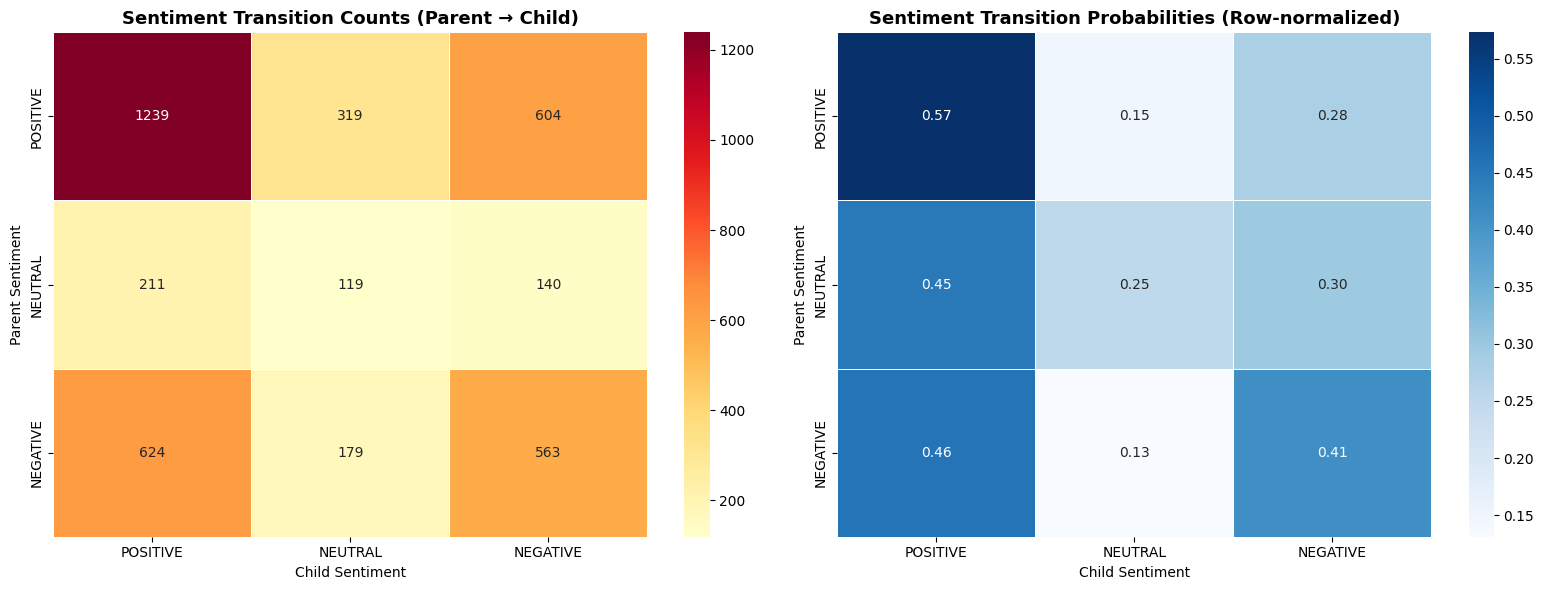


Interpretation - Sentiment Transition Heatmaps:
The first heatmap shows the raw number of parent-child sentiment transitions.
The second heatmap shows row-normalized probabilities, meaning that each row represents the distribution of child sentiments given a specific parent sentiment.

High values on the diagonal suggest sentiment persistence, where replies tend to keep the same emotional tone as the parent comment.
High off-diagonal values suggest sentiment shifts, such as a negative reply following a positive parent comment, or a positive reply following a negative parent comment.
This helps us understand whether sentiment spreads consistently or changes during discussion.



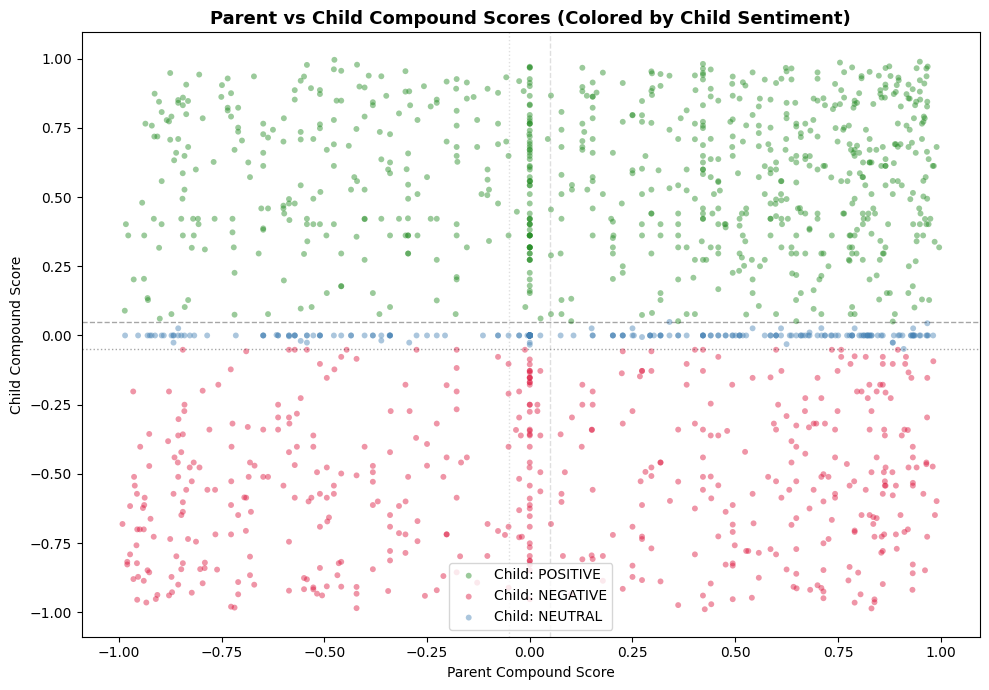


Interpretation - Parent vs Child Compound Scores:
This scatterplot compares the continuous VADER compound score of parent comments with the compound score of their child replies.
If many points appear in similar sentiment regions, this suggests that replies often preserve the emotional tone of the parent comment.
Points in opposite regions indicate sentiment reversal, where a reply responds with a different emotional tone.

For example, a parent with a positive compound score may receive a negative reply, which can indicate disagreement, criticism, or emotional contrast in the conversation.



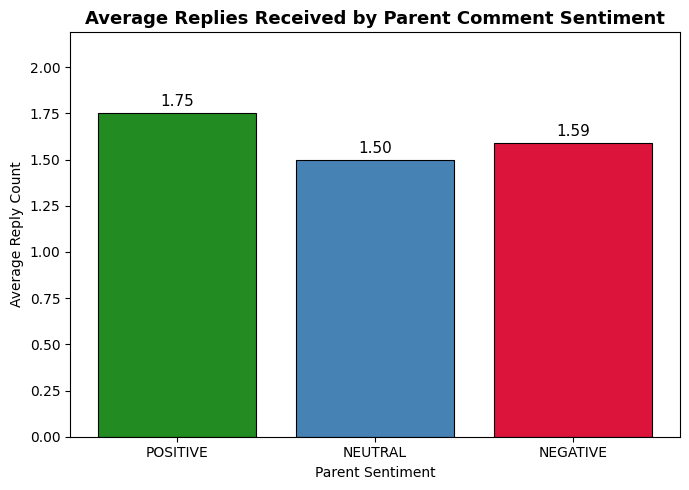

Average replies received by parent sentiment:
sentiment_vader
POSITIVE    1.750607
NEUTRAL     1.496815
NEGATIVE    1.590221

Interpretation - Average Replies by Sentiment:
This chart examines whether some sentiment categories attract more replies than others.
A higher average reply count means that comments with that sentiment tend to generate more direct responses.

If negative comments receive more replies on average, this may suggest that negative or controversial comments trigger more discussion.
If positive or neutral comments receive more replies, it may suggest that supportive or informational comments are more likely to continue the conversation.

Depth summary:
count    7425.000000
mean        2.256970
std         1.900817
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        30.000000
Name: depth, dtype: float64


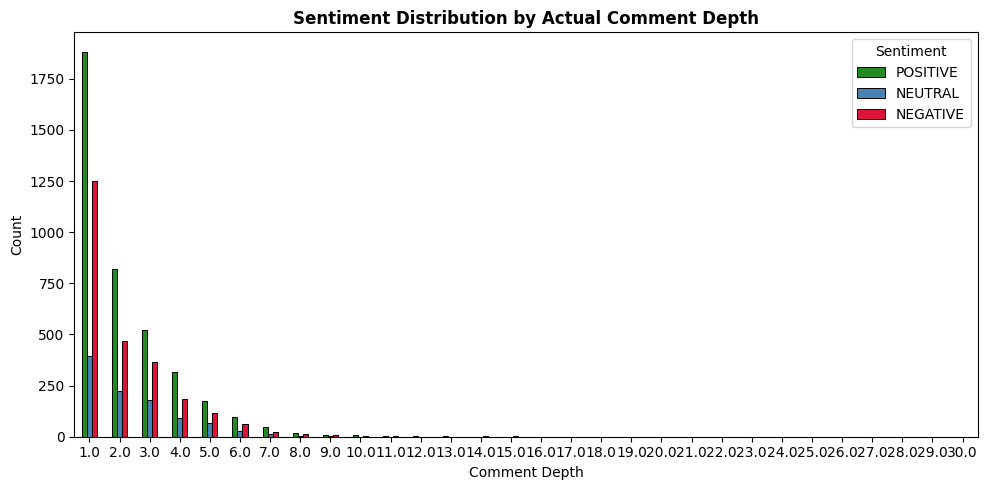


Interpretation - Sentiment by Depth:
This chart examines whether sentiment changes as comments become deeper in the discussion thread.
Depth 1 represents top-level comments replying directly to the original post.
Depth 2 and above represent nested replies.

If negative comments become more common at deeper levels, this may suggest that conversations become more emotionally charged as reply chains continue.
If neutral comments dominate across all depths, it may suggest that discussions mostly remain informational or balanced.
This analysis helps answer whether sentiment affects how deeply comments nest into conversations.

Sentiment transition count table:


child_sentiment,POSITIVE,NEUTRAL,NEGATIVE
parent_sentiment,,,
POSITIVE,1239,319,604
NEUTRAL,211,119,140
NEGATIVE,624,179,563


Sentiment transition probability table:


child_sentiment,POSITIVE,NEUTRAL,NEGATIVE
parent_sentiment,,,
POSITIVE,0.573,0.148,0.279
NEUTRAL,0.449,0.253,0.298
NEGATIVE,0.457,0.131,0.412


In [33]:
# ============================================================
# Sentiment Relationships in Reddit-Style Threaded Discussions
# ============================================================

# In this task, we analyze how sentiment flows between parent and child comments.
# We treat each comment as a node, and each reply relationship as a directed edge:
#
# parent comment  --->  child comment
#
# In Reddit data:
# - parent_id starting with "t3_" means the comment replies directly to a post.
# - parent_id starting with "t1_" means the comment replies to another comment.
#
# For sentiment propagation, we focus mainly on "t1_" relationships because
# they allow us to compare the sentiment of a parent comment with the sentiment
# of its direct child reply.

# ------------------------------------------------------------
# Required imports
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment import SentimentIntensityAnalyzer


# ------------------------------------------------------------
# 0. Make sure sentiment score exists
# ------------------------------------------------------------

# If Compound_Score was not created earlier, create it using VADER.
# Compound_Score is a continuous sentiment score between -1 and +1.
# It helps us compare sentiment intensity, not only sentiment labels.
if "Compound_Score" not in df.columns:
    vader = SentimentIntensityAnalyzer()
    df["Compound_Score"] = df["clean_body"].apply(
        lambda x: vader.polarity_scores(str(x))["compound"]
    )


# ------------------------------------------------------------
# 1. Save and reload processed dataframe
# ------------------------------------------------------------

# We drop embedding and tokens before saving because they are not needed
# for this relationship analysis and may make the CSV unnecessarily large.
df.drop(columns=["embedding", "tokens"], errors="ignore").to_csv(
    "/content/final_labels_with_sentiment.csv",
    index=False
)

dataset = pd.read_csv("/content/final_labels_with_sentiment.csv")

print(f"Loaded: {len(dataset)} rows")
print("Available columns:")
print(dataset.columns.tolist())


# ------------------------------------------------------------
# 2. Build parent-child comment pairs
# ------------------------------------------------------------

# Select only comments that reply to another comment.
# These are the rows where parent_id starts with "t1_".
nested = dataset[
    dataset["parent_id"].astype(str).str.startswith("t1_")
].copy()

# Remove the "t1_" prefix to obtain the actual parent comment_id.
nested["parent_comment_id"] = nested["parent_id"].astype(str).str.replace(
    "t1_",
    "",
    regex=False
)

# Prepare parent information.
# This gives us the sentiment and compound score of each possible parent comment.
parent_info = dataset[["comment_id", "sentiment_vader", "Compound_Score"]].rename(
    columns={
        "comment_id": "parent_comment_id",
        "sentiment_vader": "parent_sentiment",
        "Compound_Score": "parent_compound"
    }
)

# Merge child comments with their parent comments.
# Inner join keeps only the cases where the parent comment exists in the dataset.
pairs = nested.merge(parent_info, on="parent_comment_id", how="inner")

# Rename the child's own sentiment columns for clarity.
pairs = pairs.rename(
    columns={
        "sentiment_vader": "child_sentiment",
        "Compound_Score": "child_compound"
    }
)

print(f"Nested comments found: {len(nested)}")
print(f"Parent-child pairs found after merge: {len(pairs)}")


print("""
Network structure justification:
In this analysis, each Reddit comment is treated as a node.
A directed edge is created from a parent comment to a child comment when a comment replies to another comment.
The edge direction follows the conversation flow: parent -> child.
This structure is suitable because it allows us to inspect sentiment transitions, reply behavior, and emotional propagation across threaded discussions.
""")


# ------------------------------------------------------------
# I. Sentiment Transition Heatmaps
# ------------------------------------------------------------

order = ["POSITIVE", "NEUTRAL", "NEGATIVE"]

# Count how often each parent sentiment leads to each child sentiment.
trans_counts = pd.crosstab(
    pairs["parent_sentiment"],
    pairs["child_sentiment"]
)

trans_counts = trans_counts.reindex(
    index=order,
    columns=order,
    fill_value=0
)

# Row-normalized transition probabilities.
# Each row sums to 1.
# This shows: given a parent sentiment, what is the probability of each child sentiment?
trans_prob = trans_counts.div(trans_counts.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    trans_counts,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    ax=axes[0],
    linewidths=0.5
)

axes[0].set_title(
    "Sentiment Transition Counts (Parent → Child)",
    fontsize=13,
    fontweight="bold"
)
axes[0].set_xlabel("Child Sentiment")
axes[0].set_ylabel("Parent Sentiment")


sns.heatmap(
    trans_prob,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=axes[1],
    linewidths=0.5
)

axes[1].set_title(
    "Sentiment Transition Probabilities (Row-normalized)",
    fontsize=13,
    fontweight="bold"
)
axes[1].set_xlabel("Child Sentiment")
axes[1].set_ylabel("Parent Sentiment")

plt.tight_layout()
plt.show()


print("""
Interpretation - Sentiment Transition Heatmaps:
The first heatmap shows the raw number of parent-child sentiment transitions.
The second heatmap shows row-normalized probabilities, meaning that each row represents the distribution of child sentiments given a specific parent sentiment.

High values on the diagonal suggest sentiment persistence, where replies tend to keep the same emotional tone as the parent comment.
High off-diagonal values suggest sentiment shifts, such as a negative reply following a positive parent comment, or a positive reply following a negative parent comment.
This helps us understand whether sentiment spreads consistently or changes during discussion.
""")


# ------------------------------------------------------------
# II. Parent vs Child Compound Score Scatterplot
# ------------------------------------------------------------

# Sample for visualization if the dataset is large.
sample = pairs.sample(
    min(1500, len(pairs)),
    random_state=42
)

color_map = {
    "POSITIVE": "forestgreen",
    "NEGATIVE": "crimson",
    "NEUTRAL": "steelblue"
}

fig, ax = plt.subplots(figsize=(10, 7))

for sentiment, color in color_map.items():
    mask = sample["child_sentiment"] == sentiment

    ax.scatter(
        sample.loc[mask, "parent_compound"],
        sample.loc[mask, "child_compound"],
        c=color,
        label=f"Child: {sentiment}",
        alpha=0.45,
        s=18,
        edgecolors="none"
    )

# VADER thresholds
ax.axhline(y=0.05, color="black", linestyle="--", alpha=0.35, lw=1)
ax.axhline(y=-0.05, color="black", linestyle=":", alpha=0.35, lw=1)
ax.axvline(x=0.05, color="gray", linestyle="--", alpha=0.25, lw=1)
ax.axvline(x=-0.05, color="gray", linestyle=":", alpha=0.25, lw=1)

ax.set_title(
    "Parent vs Child Compound Scores (Colored by Child Sentiment)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Parent Compound Score")
ax.set_ylabel("Child Compound Score")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


print("""
Interpretation - Parent vs Child Compound Scores:
This scatterplot compares the continuous VADER compound score of parent comments with the compound score of their child replies.
If many points appear in similar sentiment regions, this suggests that replies often preserve the emotional tone of the parent comment.
Points in opposite regions indicate sentiment reversal, where a reply responds with a different emotional tone.

For example, a parent with a positive compound score may receive a negative reply, which can indicate disagreement, criticism, or emotional contrast in the conversation.
""")


# ------------------------------------------------------------
# III. Average Replies Received by Parent Sentiment
# ------------------------------------------------------------

# Count how many direct replies each parent comment received.
reply_counts = (
    pairs.groupby("parent_comment_id")["child_sentiment"]
    .count()
    .reset_index(name="n_replies")
)

# Add the sentiment of each parent comment.
reply_counts = reply_counts.merge(
    dataset[["comment_id", "sentiment_vader"]].rename(
        columns={"comment_id": "parent_comment_id"}
    ),
    on="parent_comment_id",
    how="left"
)

# Compute average number of replies by parent sentiment.
avg_replies = (
    reply_counts.groupby("sentiment_vader")["n_replies"]
    .mean()
    .reindex(order)
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    avg_replies.index,
    avg_replies.values,
    color=["forestgreen", "steelblue", "crimson"],
    edgecolor="black",
    lw=0.8
)

plt.bar_label(bars, fmt="%.2f", padding=3, fontsize=11)

plt.title(
    "Average Replies Received by Parent Comment Sentiment",
    fontsize=13,
    fontweight="bold"
)
plt.xlabel("Parent Sentiment")
plt.ylabel("Average Reply Count")

if avg_replies.max() > 0:
    plt.ylim(0, avg_replies.max() * 1.25)

plt.tight_layout()
plt.show()

print("Average replies received by parent sentiment:")
print(avg_replies.to_string())


print("""
Interpretation - Average Replies by Sentiment:
This chart examines whether some sentiment categories attract more replies than others.
A higher average reply count means that comments with that sentiment tend to generate more direct responses.

If negative comments receive more replies on average, this may suggest that negative or controversial comments trigger more discussion.
If positive or neutral comments receive more replies, it may suggest that supportive or informational comments are more likely to continue the conversation.
""")


# ------------------------------------------------------------
# IV. Compute Actual Comment Depth
# ------------------------------------------------------------

# Build a dictionary mapping each comment_id to its parent_id.
parent_map = dict(zip(dataset["comment_id"], dataset["parent_id"]))

def compute_depth(comment_id):
    """
    Compute the actual depth of a comment in the Reddit thread.

    depth = 1 means the comment replies directly to the original post.
    depth = 2 means the comment replies to a top-level comment.
    depth = 3+ means the comment is deeper in the conversation chain.
    """

    depth = 0
    current_id = comment_id

    while True:
        parent_id = parent_map.get(current_id)

        if pd.isna(parent_id):
            return np.nan

        parent_id = str(parent_id)

        # Parent is the original post.
        if parent_id.startswith("t3_"):
            return depth + 1

        # Parent is another comment.
        elif parent_id.startswith("t1_"):
            current_id = parent_id.replace("t1_", "", 1)
            depth += 1

            # Safety stop to avoid infinite loops in corrupted data.
            if depth > 50:
                return np.nan

        else:
            return np.nan


dataset["depth"] = dataset["comment_id"].apply(compute_depth)

print("Depth summary:")
print(dataset["depth"].describe())


# ------------------------------------------------------------
# V. Sentiment Distribution by Actual Comment Depth
# ------------------------------------------------------------

depth_dist = (
    dataset.groupby(["depth", "sentiment_vader"])
    .size()
    .unstack(fill_value=0)
)

depth_dist = depth_dist.reindex(columns=order, fill_value=0)

depth_dist.plot(
    kind="bar",
    figsize=(10, 5),
    color=["forestgreen", "steelblue", "crimson"],
    edgecolor="black",
    lw=0.7
)

plt.title(
    "Sentiment Distribution by Actual Comment Depth",
    fontsize=12,
    fontweight="bold"
)
plt.xlabel("Comment Depth")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


print("""
Interpretation - Sentiment by Depth:
This chart examines whether sentiment changes as comments become deeper in the discussion thread.
Depth 1 represents top-level comments replying directly to the original post.
Depth 2 and above represent nested replies.

If negative comments become more common at deeper levels, this may suggest that conversations become more emotionally charged as reply chains continue.
If neutral comments dominate across all depths, it may suggest that discussions mostly remain informational or balanced.
This analysis helps answer whether sentiment affects how deeply comments nest into conversations.
""")


# ------------------------------------------------------------
# VI. Optional: Sentiment Transition Summary Table
# ------------------------------------------------------------

print("Sentiment transition count table:")
display(trans_counts)

print("Sentiment transition probability table:")
display(trans_prob.round(3))

# **ADDITIONAL PART**


# **I. Scrape and Analyze Your Own Reddit Data**

Take your analysis to the next level by collecting and analyzing **your own custom Reddit dataset**!  
In this bonus task, you'll get hands-on experience with **web scraping**, **API usage**, and **exploratory sentiment analysis**.

---

## What You Can Do

You can use the Reddit API (via the `praw` Python library) to:
- Scrape comment threads from a subreddit of your choice
- Structure the data to capture **parent-child relationships**
- Apply the same **sentiment transition** and **network analysis** workflow from the main task

---

## Step-by-Step: Scraping Reddit Data

### Step 1: Get Your Reddit API Credentials

To use Reddit's API, you need to create an app on Reddit and get your access keys.

1. **Log in to Reddit** with your account.
2. Go to your [apps page](https://www.reddit.com/prefs/apps).
3. Scroll down and click **“Create another app…”**
4. Fill out the form:
   - **name**: e.g. `RedditSentimentScraper`
   - **type**: select `script`
   - **description**: optional
   - **about url**: leave blank
   - **redirect uri**: type `http://localhost:8080` (it won’t be used for this project)
5. Click **create app**

Once you submit the form, Reddit will show you:
- `username` → The string on the right of `developers`
- `client_id` → The code **just under the app name**
- `client_secret` → The **“secret”** string under the icon of the app
- `user_agent` → A custom description of your app, e.g., `"web:my-app:v0.1 (by u/YourUsername)"`

---

### Step 2: Store Your Credentials in a File

Create a new file named `my-env.sh` in your project folder:

```bash
# my-env.sh

# Reddit API credentials
REDDIT_USERNAME="YourRedditUsername"
REDDIT_CLIENT_ID="your-client-id-here"
REDDIT_CLIENT_SECRET="your-client-secret-here"
REDDIT_USER_AGENT="web:reddit-analysis:v0.1 (by u/$REDDIT_USERNAME)"
REDDIT_PASSWORD=YourPassword

```

### Step 3: Run the code below!



In [ ]:
!pip install praw python-dotenv


In [ ]:
import os
import praw
import pandas as pd
from dotenv import load_dotenv

load_dotenv("env.env")

# Initialize Reddit API
reddit = praw.Reddit(
    client_id=os.environ['REDDIT_CLIENT_ID'],
    client_secret=os.environ['REDDIT_CLIENT_SECRET'],
    user_agent="script:comment-grabber:v0.0.1 (by u/{})".format(os.environ['REDDIT_USERNAME'])
)

subreddit = reddit.subreddit("AskReddit")

# List to store comment data
comments_data = []

for submission in subreddit.hot(limit=1):
    submission.comments.replace_more(limit=None)
    for comment in submission.comments.list():
        if comment.body != "[deleted]" and comment.author is not None:
            comments_data.append({
                'post_id': submission.id,
                'post_title': submission.title,
                'comment_id': comment.id,
                'parent_id': comment.parent_id,
                'author': str(comment.author),
                'body': comment.body,
                'score': comment.score,
                'created_utc': comment.created_utc
            })

# Create DataFrame
df = pd.DataFrame(comments_data)
df.to_csv('AskReddit.csv')

In [ ]:
# Apply the full sentiment analysis pipeline to the scraped AskReddit data

# Load the scraped data
df_reddit = pd.read_csv('AskReddit.csv')
df_reddit = df_reddit.dropna(subset=["body"])
df_reddit["clean_body"] = df_reddit["body"].astype(str).apply(clean_text)
print(f"AskReddit dataset: {len(df_reddit)} comments")

# VADER sentiment scores
sia2 = SentimentIntensityAnalyzer()
vader_scores2 = df_reddit["clean_body"].apply(lambda x: sia2.polarity_scores(str(x)))
df_reddit["Negative_Score"] = vader_scores2.apply(lambda x: x["neg"])
df_reddit["Neutral_Score"]  = vader_scores2.apply(lambda x: x["neu"])
df_reddit["Positive_Score"] = vader_scores2.apply(lambda x: x["pos"])
df_reddit["Compound_Score"] = vader_scores2.apply(lambda x: x["compound"])
df_reddit["sentiment_vader"] = df_reddit["clean_body"].apply(get_vader_label)

print("\nSentiment distribution in AskReddit:")
print(df_reddit["sentiment_vader"].value_counts())

# Visualise compound score distribution
plt.figure(figsize=(10, 4))
sns.histplot(df_reddit["Compound_Score"], bins=50, kde=True, color="steelblue", alpha=0.7)
plt.axvline(df_reddit["Compound_Score"].mean(), color="black", linestyle="--",
            label=f'Mean: {df_reddit["Compound_Score"].mean():.3f}')
plt.title("AskReddit — Compound Score Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Compound Score"); plt.ylabel("Count")
plt.legend(); plt.tight_layout(); plt.show()

# Sentiment relationship analysis: parent -> child transitions
nested_r = df_reddit[df_reddit["parent_id"].str.startswith("t1_")].copy()
nested_r["parent_comment_id"] = nested_r["parent_id"].str.replace("t1_", "", regex=False)

parent_info_r = df_reddit[["comment_id", "sentiment_vader"]].rename(
    columns={"comment_id": "parent_comment_id", "sentiment_vader": "parent_sentiment"})
pairs_r = nested_r.merge(parent_info_r, on="parent_comment_id", how="inner")
pairs_r = pairs_r.rename(columns={"sentiment_vader": "child_sentiment"})
print(f"\nParent-child pairs in AskReddit: {len(pairs_r)}")

if len(pairs_r) > 0:
    order = ["POSITIVE", "NEUTRAL", "NEGATIVE"]
    trans_r = pd.crosstab(pairs_r["parent_sentiment"], pairs_r["child_sentiment"])
    trans_r = trans_r.reindex(index=order, columns=order, fill_value=0)
    trans_r_prob = trans_r.div(trans_r.sum(axis=1), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(trans_r,      annot=True, fmt="d",   cmap="YlOrRd", ax=axes[0], linewidths=0.5)
    axes[0].set_title("AskReddit — Transition Counts",         fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Child Sentiment"); axes[0].set_ylabel("Parent Sentiment")
    sns.heatmap(trans_r_prob, annot=True, fmt=".2f", cmap="Blues",  ax=axes[1], linewidths=0.5)
    axes[1].set_title("AskReddit — Transition Probabilities", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Child Sentiment"); axes[1].set_ylabel("Parent Sentiment")
    plt.tight_layout(); plt.show()
else:
    print("Not enough nested replies to compute transition matrix (only 1 post scraped).")
    print("Re-run cell 42 with limit=5 or more to get richer data.")

# **II. Explore Advanced Embeddings and Classifiers**

Go beyond Word2Vec and experiment with **modern embedding techniques** such as **BERT**, **RoBERTa**, or **SBERT**, which generate **context-aware** representations of entire sentences and comments.  
Once you’ve embedded your text, try using alternative classifiers like **k-Nearest Neighbors (KNN)**, **Logistic Regression**, or even **Gradient Boosted Trees** to compare performance on sentiment classification tasks.

> How do results change with better embeddings? Which model handles the structure of your data best?  
> This is your chance to push your pipeline further and discover what works best for your data!



In [ ]:
# Advanced Embeddings: SBERT (Sentence-BERT) — context-aware sentence vectors
from sentence_transformers import SentenceTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── 1. Generate SBERT embeddings ─────────────────────────────────────────────
print("Loading SBERT model (all-MiniLM-L6-v2)...")
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding comments with SBERT...")
X_sbert = sbert_model.encode(df["clean_body"].tolist(), batch_size=64,
                              show_progress_bar=True, convert_to_numpy=True)
print(f"SBERT embedding shape: {X_sbert.shape}")

# ── 2. Encode labels and balance classes ─────────────────────────────────────
le2 = LabelEncoder()
y_sbert = le2.fit_transform(df["sentiment_vader"])

data_s = pd.DataFrame({"emb": list(X_sbert), "label": y_sbert})
maj_label = data_s["label"].value_counts().idxmax()
data_maj  = data_s[data_s["label"] == maj_label]
resampled_s = [resample(data_s[data_s["label"] == l], replace=True,
                         n_samples=len(data_maj), random_state=42)
               for l in data_s["label"].unique() if l != maj_label]
data_bal_s  = pd.concat([data_maj] + resampled_s).sample(frac=1, random_state=42).reset_index(drop=True)
X_bal_s = np.stack(data_bal_s["emb"])
y_bal_s = data_bal_s["label"].values

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_bal_s, y_bal_s, test_size=0.2, random_state=42, stratify=y_bal_s)
print(f"Train: {len(X_tr_s)}  |  Test: {len(X_te_s)}")

# ── 3. Train and evaluate three classifiers ───────────────────────────────────
classifiers = {
    "KNN (k=5)":              KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Logistic Regression":    LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boosting":      GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, clf in classifiers.items():
    print(f"\n=== {name} ===")
    clf.fit(X_tr_s, y_tr_s)
    y_pred_s = clf.predict(X_te_s)
    print(classification_report(y_te_s, y_pred_s, target_names=le2.classes_))
    results[name] = clf.score(X_te_s, y_te_s)

    cm = confusion_matrix(y_te_s, y_pred_s)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le2.classes_, yticklabels=le2.classes_)
    plt.title(f"Confusion Matrix — {name}", fontsize=11, fontweight="bold")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()

# ── 4. Accuracy comparison: SBERT classifiers vs FastText + RandomForest ──────
results["FastText + RandomForest (baseline)"] = rf_model.score(X_test, y_test)

plt.figure(figsize=(9, 5))
bars = plt.bar(results.keys(), results.values(),
               color=["steelblue", "forestgreen", "darkorange", "crimson"],
               edgecolor="black", linewidth=0.8)
plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
plt.title("Test Accuracy Comparison: SBERT Classifiers vs FastText Baseline",
          fontsize=12, fontweight="bold")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()

print("\nSummary:")
for name, acc in results.items():
    print(f"  {name}: {acc:.4f}")